# **importation des Bibliothèques**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Chargement du Jeu de Donnée**<br>
### **on charge le fichier csv dans une variable appele diabete_data, c'est comme un tableau excel**


In [2]:
diabete_data = pd.read_csv("../data/diabetes.csv")
print("Dataset charger")
print(f"{diabete_data.shape[0]} lignes et {diabete_data.shape[1]} colonnes")
diabete_data

Dataset charger
768 lignes et 9 colonnes


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
print(f"{diabete_data.dtypes}\n")

explications = {
    "Pregnancies" : "nbre de grossesses",
    "Glucose" : "Taux de glucose dans le sang en mg/dL",
    "BloodPressure" : "Pression arterielle diastolique en mm Hg",
    "SkinThickness" : "Epaisseur du pli cutané du triceps en mm",
    "Insulin" : "Taux d'insuline sur 2 heures en mu U/ml",
    "BMI" : "Indidice de masse corporelle (IMC)",
    "DiabetesPedigreeFunction" : "Antecedents familiaux de diabète(score)",
    "Age" : "Age du patient en annees",
    "Outcome" : "Resultat: 0 = Non diabetique/ 1 = Diabetique"
}
print("Explication de chaque colone :\n")
for colonne,signification in explications.items():
    print(f" - {colonne} : {signification}")


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Explication de chaque colone :

 - Pregnancies : nbre de grossesses
 - Glucose : Taux de glucose dans le sang en mg/dL
 - BloodPressure : Pression arterielle diastolique en mm Hg
 - SkinThickness : Epaisseur du pli cutané du triceps en mm
 - Insulin : Taux d'insuline sur 2 heures en mu U/ml
 - BMI : Indidice de masse corporelle (IMC)
 - DiabetesPedigreeFunction : Antecedents familiaux de diabète(score)
 - Age : Age du patient en annees
 - Outcome : Resultat: 0 = Non diabetique/ 1 = Diabetique


# **Statistiques descriptives**

In [4]:
print('='*50)   
print(f"Statisques du dataset:\n {diabete_data.describe()}")

Statisques du dataset:
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.

#### **Valeurs manquuantes...**

In [5]:
print(f"Nombre de valeurs manquantes par colonne:\n {diabete_data.isnull().sum()}\n")

Nombre de valeurs manquantes par colonne:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64



In [6]:
colonne = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("Nombre de zeros par colone\n")

for col in colonne:
    nbre_zero = (diabete_data[col] == 0).sum()
    pourcentage = (nbre_zero / len(diabete_data))*100
    
    print(f" - {col} : {nbre_zero} zeros ({pourcentage:.1f}% des donnees)")

Nombre de zeros par colone

 - Glucose : 5 zeros (0.7% des donnees)
 - BloodPressure : 35 zeros (4.6% des donnees)
 - SkinThickness : 227 zeros (29.6% des donnees)
 - Insulin : 374 zeros (48.7% des donnees)
 - BMI : 11 zeros (1.4% des donnees)


#### **conclusion: on constate des cas ou il y a plus de 0 ce qui est grave car ces impossibles. comme un taux de glucose a 0 sa n'existe pas,donc ces 0 sont considere comme des valeurs manquantes mal encodees.<br> on va resoud ce probleme en rmplacant tous ces zeros par la mediane de chaqe colonne prcqu'elle est moins sensibles au valeurs extremes.**

# **Repartition des cas Diabetiques et non Diabetiiques**

Repartition de la colonne cible Outcome:

 - Non Diabetiques (0) : 500 personnes
 - Diabetiques (1) : 268 personnes


 Ratio diabetiques : 34.9%


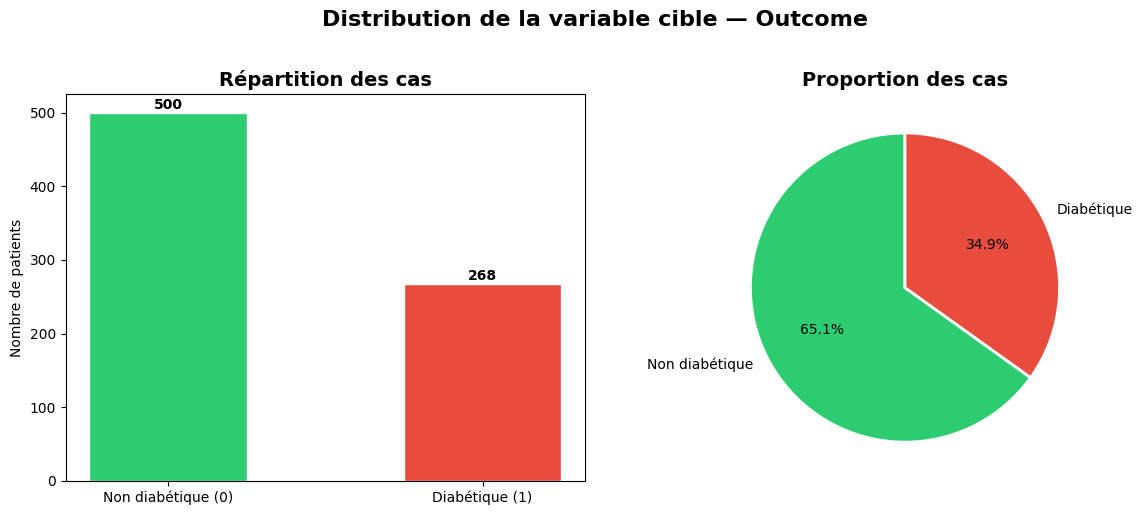

In [7]:
repartition = diabete_data["Outcome"].value_counts()
print(f"Repartition de la colonne cible Outcome:\n")
print(f" - Non Diabetiques (0) : {repartition[0]} personnes")
print(f" - Diabetiques (1) : {repartition[1]} personnes\n")
print(f"\n Ratio diabetiques : {repartition[1]/len(diabete_data)*100:.1f}%")

# graphique pour visualiser
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(
    ["Non diabétique (0)", "Diabétique (1)"], 
    [repartition[0],repartition[1]],                   
    color=["#2ECC71", "#E74C3C"],              
    edgecolor="white",
    width=0.5
)
axes[0].set_title("Répartition des cas", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Nombre de patients")

for i,valeur in enumerate([repartition[0], repartition[1]]):
    axes[0].text(i, valeur +5,str(valeur), ha="center", fontweight="bold")

axes[1].pie(
    [repartition[0], repartition[1]],    
    labels=["Non diabétique", "Diabétique"], 
    colors=["#2ECC71", "#E74C3C"], 
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Proportion des cas", fontsize=14, fontweight="bold")

plt.suptitle("Distribution de la variable cible — Outcome", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# **Distribution de toutes les colonne**

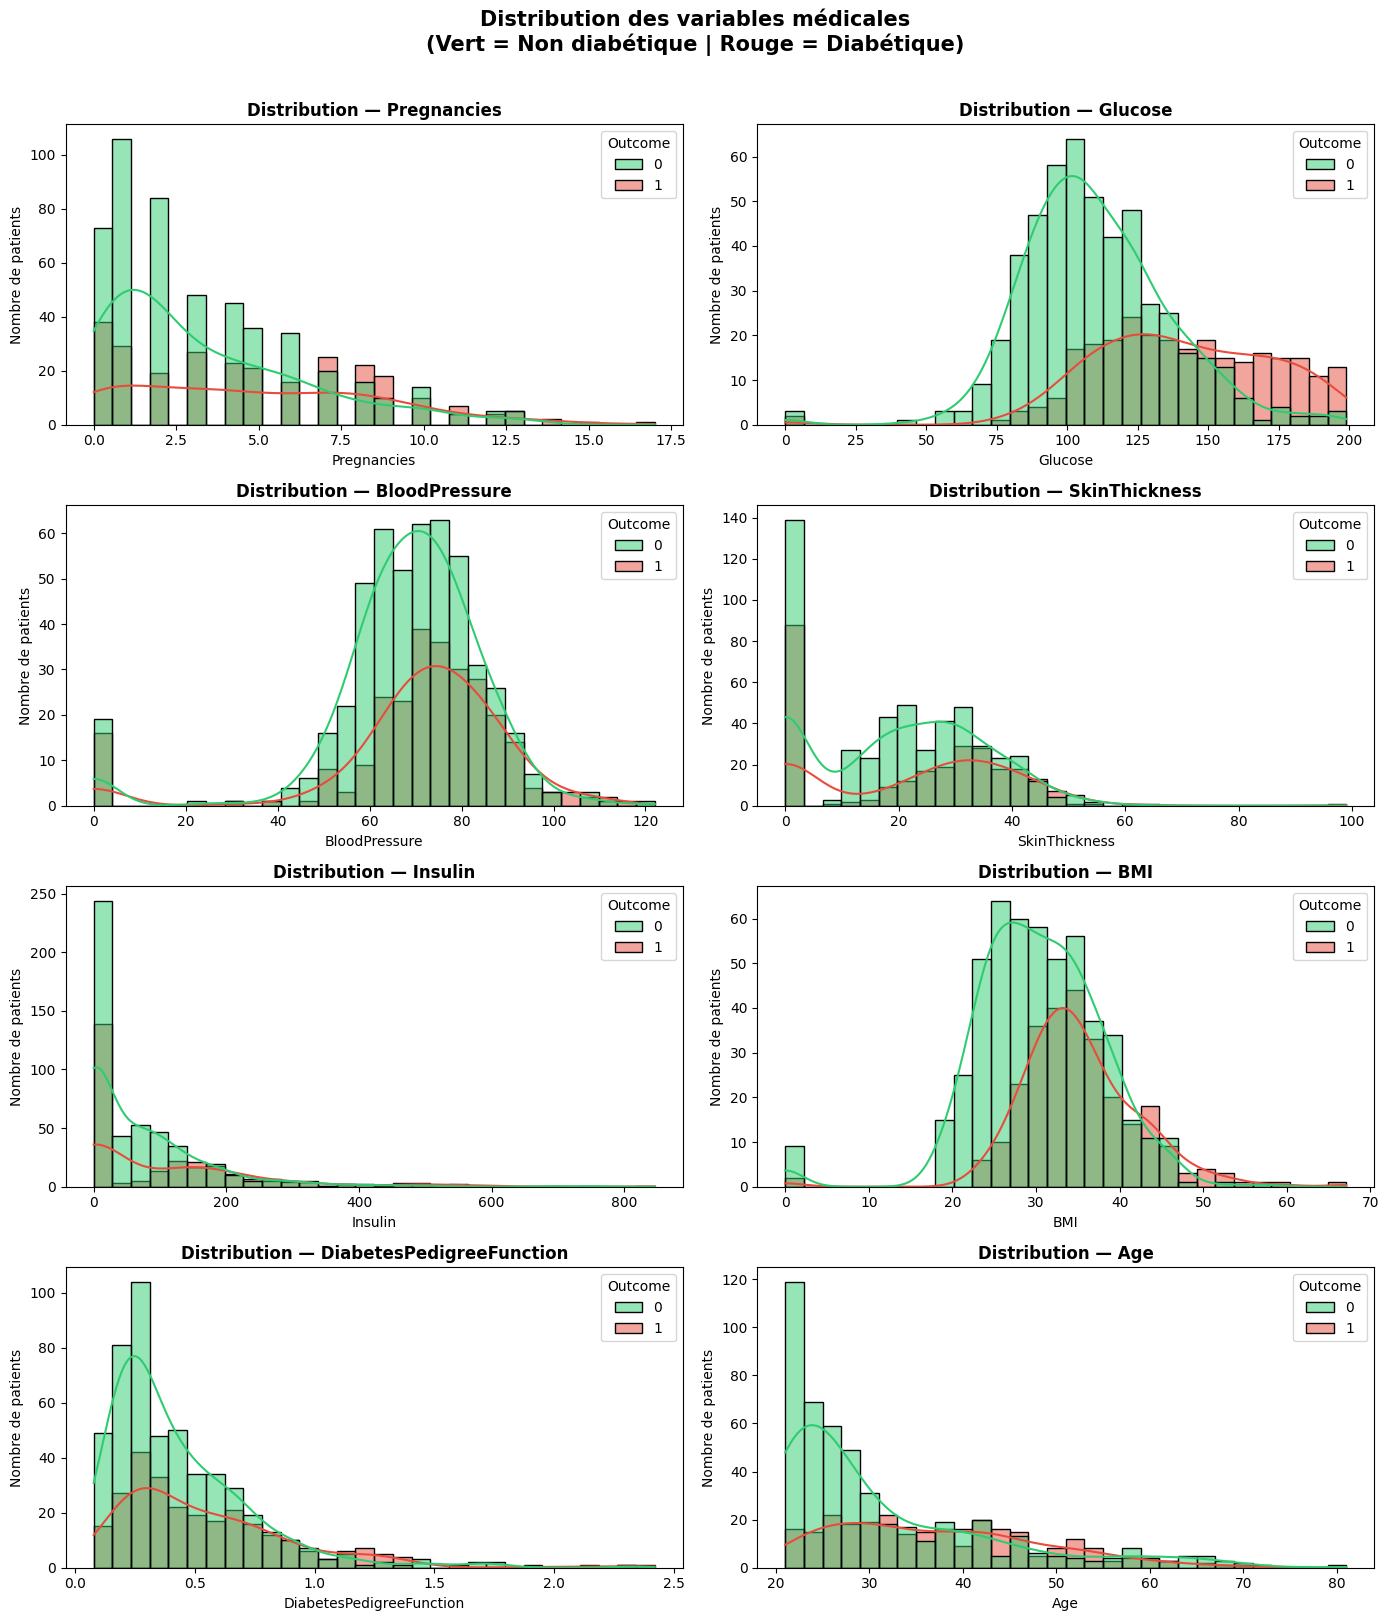

In [8]:
colonnes = ["Pregnancies","Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(colonnes):
    sns.histplot(data=diabete_data,x=col,hue="Outcome",kde=True,ax=axes[i],palette={0: "#2ECC71", 1: "#E74C3C"},bins=30)
    axes[i].set_title(f"Distribution — {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre de patients")

plt.suptitle("Distribution des variables médicales\n(Vert = Non diabétique | Rouge = Diabétique)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# **Matrice de correlation**

##### **correlation entre les deux variable  va messurer le lien entre deux variable entre -1 et 1 ,1 quand l'une monte l'autre monte aussi ce qui veut dire qu'il ya un lien fort positif,-1 quand l'une monte et l'autre descend ce qui veut dire il y a un lien fort negatif  et 0 pas de lien entre les deux**

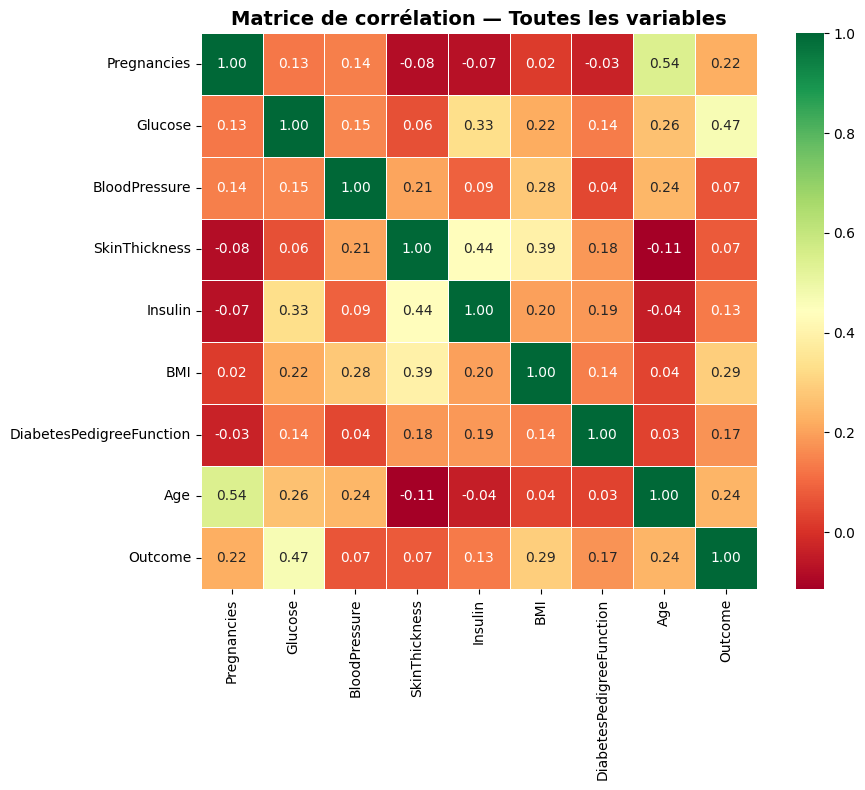

correlation de chaque variable avec Outcome du plus fort au plus faible :

 - Glucose : 0.467
 - BMI : 0.293
 - Age : 0.238
 - Pregnancies : 0.222
 - DiabetesPedigreeFunction : 0.174
 - Insulin : 0.131
 - SkinThickness : 0.075
 - BloodPressure : 0.065


In [9]:
matrice_corr = diabete_data.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(matrice_corr,annot=True,fmt=".2f",cmap="RdYlGn",linewidths=0.5,square=True)

plt.title("Matrice de corrélation — Toutes les variables", 
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("correlation de chaque variable avec Outcome du plus fort au plus faible :\n")
corr_outcome = matrice_corr["Outcome"].drop("Outcome").sort_values(ascending=False)

for col, valeur in corr_outcome.items():
    print(f" - {col} : {valeur:.3f}")

### **conclusion: a travers la matrice de correlation on vois que le glucose et l"IMC et l'age sont les 3 variable qui peuvent nous permet de determiner la prediction du diabete.**

# **nettoyage des zeros**

In [10]:
cp_diabete_data = diabete_data.copy()
colonnee = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("rmplacer les zeros par la mediane \n")

for col in colonnee:
    mediane = cp_diabete_data[col][cp_diabete_data[col] !=0].median()
    nbre_zero = (cp_diabete_data[col] == 0).sum()
    cp_diabete_data[col]= cp_diabete_data[col].replace(0,mediane)
    
    print(f" - {col} zero remplacer par la medianne ({mediane})")
    
print("verification...")
for col in colonnee:
    nbre_zero_restants = (cp_diabete_data[col] == 0).sum()    
    print(f" - {col} : {nbre_zero_restants} zeros restant")


rmplacer les zeros par la mediane 

 - Glucose zero remplacer par la medianne (117.0)
 - BloodPressure zero remplacer par la medianne (72.0)
 - SkinThickness zero remplacer par la medianne (29.0)
 - Insulin zero remplacer par la medianne (125.0)
 - BMI zero remplacer par la medianne (32.3)
verification...
 - Glucose : 0 zeros restant
 - BloodPressure : 0 zeros restant
 - SkinThickness : 0 zeros restant
 - Insulin : 0 zeros restant
 - BMI : 0 zeros restant


# sauvegarde du new dataset

In [11]:
cp_diabete_data.to_csv("../data/diabetes_clean.csv", index= False)
print(f"diemnesion {cp_diabete_data.shape[0]} lignes et {cp_diabete_data.shape[1]} colonnes")

diemnesion 768 lignes et 9 colonnes


#### **le nettoyage avais des zeros impossible je les ai remplacer par la mediane de chaque colonne**

#### **Visualisation des anomalies**

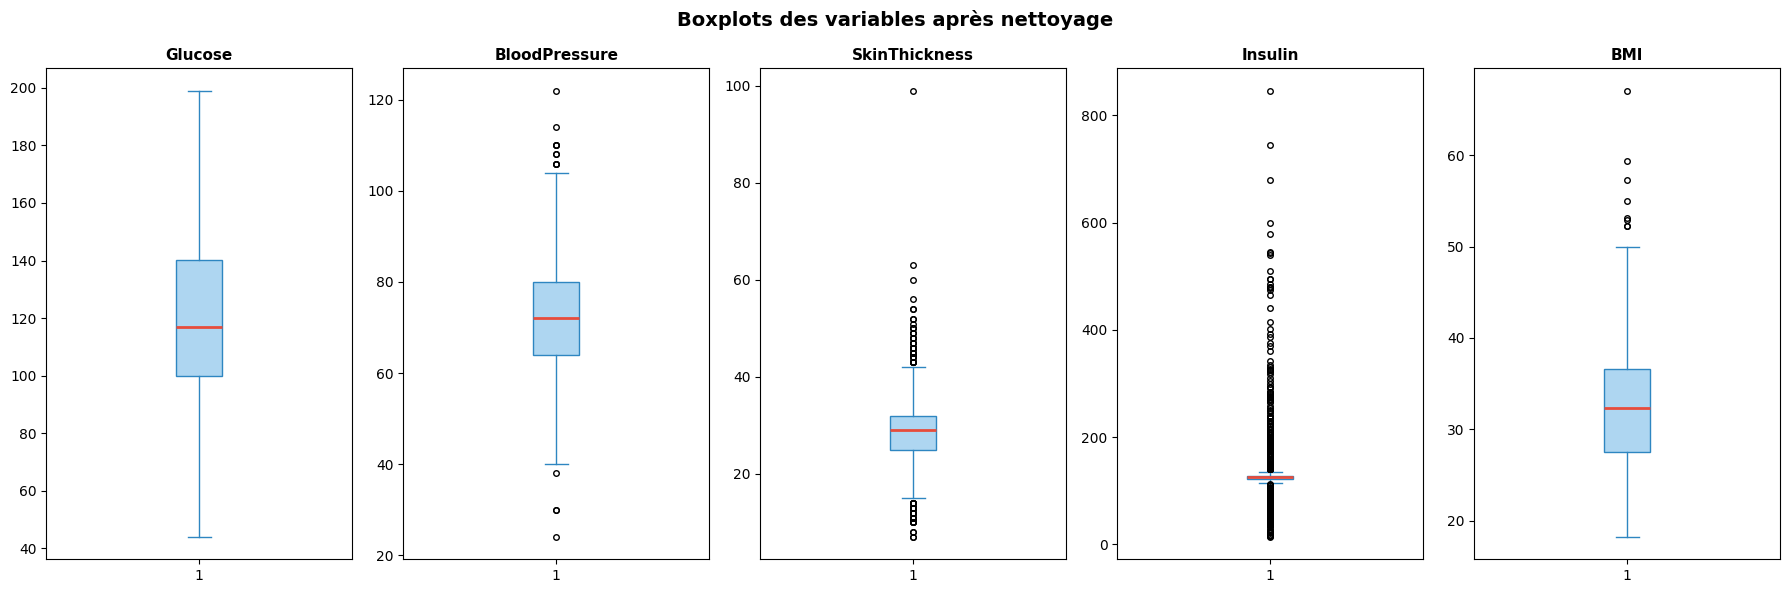

In [12]:
colonnee = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, col in enumerate(colonnee):
    axes[i].boxplot(cp_diabete_data[col],patch_artist=True,boxprops=dict(facecolor="#AED6F1", color="#2E86C1"),medianprops=dict(color="#E74C3C", linewidth=2),whiskerprops=dict(color="#2E86C1"),capprops=dict(color="#2E86C1"),flierprops=dict(marker='o', color='orange', markersize=4))
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")

plt.suptitle("Boxplots des variables après nettoyage",fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### **conclusion: apres nettoyage, les donnees sont exploitables. les valeurs qui restent maintenant sont des valeurs medicale possible car ils representent des cas reels de patients**